In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 1 * 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # (32, 13, 13)
        x = self.pool(self.relu(self.conv2(x)))  # (64, 5, 5)
        x = self.relu(self.conv3(x))  # (128, 3, 3)
        x = self.relu(self.conv4(x))  # (128, 1, 1)
        x = x.view(x.size(0), -1)  # Flatten -> 128
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [ ]:
model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss() # loss function - CSE Loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # optimizer - Adam

In [ ]:
num_epochs = 5
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        # Forward pass
        yhat = model(X)
        loss = loss_fn(yhat, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== VALIDATION (MUST BE HERE) =====
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            yhat = model(X)
            loss = loss_fn(yhat, y)

            val_loss += loss.item()
            _, preds = torch.max(yhat, 1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    avg_val_loss = val_loss / len(test_loader)
    accuracy = 100 * correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {accuracy:.2f}%"
    )

Epoch 1/5 | Train Loss: 0.2370 | Val Loss: 0.0535 | Val Acc: 98.31%
Epoch 2/5 | Train Loss: 0.0570 | Val Loss: 0.0426 | Val Acc: 98.71%
Epoch 3/5 | Train Loss: 0.0418 | Val Loss: 0.0374 | Val Acc: 98.68%
Epoch 4/5 | Train Loss: 0.0314 | Val Loss: 0.0301 | Val Acc: 98.91%
Epoch 5/5 | Train Loss: 0.0271 | Val Loss: 0.0300 | Val Acc: 99.12%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        yhat = model(X)
        _, predicted = torch.max(yhat, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.12%


val losses - [0.05351026727938789, 0.042605673697190594, 0.037413982342180054, 0.030124689480717164, 0.029976862470200875] 
train losses - [0.23695276885319239, 0.0569638075855082, 0.04182779050316971, 0.031381618868716474, 0.027144779925788644]


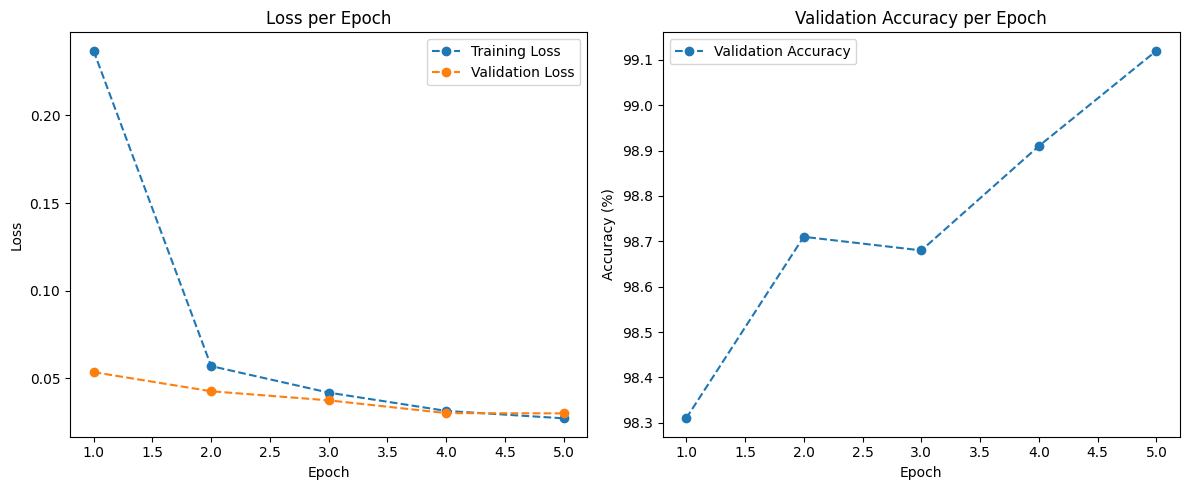

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize = (12, 5))
print(f'val losses - {val_losses} \ntrain losses - {train_losses}')
# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o--', label="Training Loss")
plt.plot(epochs, val_losses, 'o--', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, 'o--', label="Validation Accuracy",)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy per Epoch")
plt.legend()

plt.tight_layout()
plt.show()


Testing with custom data

In [ ]:
from torchvision import transforms
from PIL import Image
import torch
import os

In [ ]:
image_dir = "MNIST Custom/"


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensure 1 channel
    transforms.Resize((28, 28)),
    transforms.ToTensor(),                         # converts to [0,1]
    transforms.Lambda(lambda x: 1.0 - x),           # invert colors
    transforms.Normalize((0.1307,), (0.3081,))      # MNIST normalization
])

In [ ]:
def load_image(path):
    img = Image.open(path).convert("L")   # force grayscale
    img = transform(img)
    img = img.unsqueeze(0)                # add batch dimension
    return img

img = load_image(f'{image_dir}2.jpeg')
img = img.to(device)

In [ ]:
model.eval()
for file in os.listdir(image_dir):
    path = os.path.join(image_dir, file)

    img = load_image(path).to(device)

    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()

    print(f"{file} → {pred}")

shit 6.jpeg → 8
2.jpeg → 1
shit 9.jpeg → 1
8.jpeg → 8
shit 8.jpeg → 0
shit 7.jpeg → 1
3.jpeg → 1
4.jpeg → 1
